# 01. Load the processed Parquet

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
PROCESSED_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "household_power_consumption_clean.parquet"
)

df = pd.read_parquet(PROCESSED_PATH)

print("Shape:", df.shape)

Shape: (2075259, 12)


In [5]:
# Confirm timestamp
print(
    df["timestamp"].min(),
    "→",
    df["timestamp"].max()
)

2006-12-16 17:24:00 → 2010-11-26 21:02:00


In [6]:
target = "Global_active_power"

print(df[target].describe())

count    2.049280e+06
mean     1.091615e+00
std      1.057294e+00
min      7.600000e-02
25%      3.080000e-01
50%      6.020000e-01
75%      1.528000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64


In [7]:
print(
    "Missing:",
    df[target].isna().sum()
)

print(
    "Available:",
    df[target].notna().sum()
)

Missing: 25979
Available: 2049280


# 2. Basic target distribution

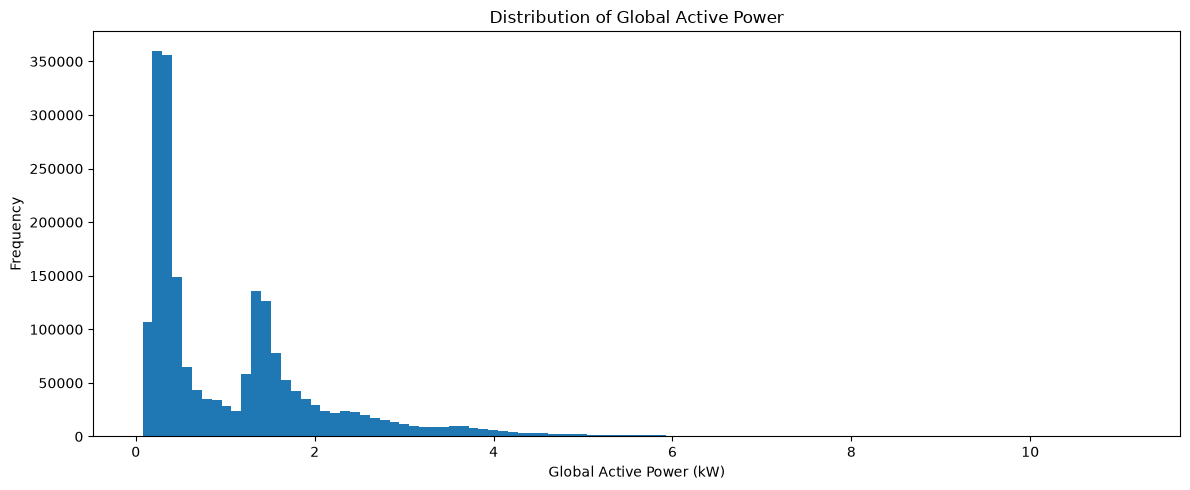

In [ ]:
plt.figure(figsize=(12, 5))

plt.hist(
    df[target].dropna(),
    bins=100
)

plt.title(
    "Distribution of Global Active Power"
)

plt.xlabel(
    "Global Active Power (kW)"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()

# 3. Time-series overview    

In [10]:
daily_power = (
    df.set_index("timestamp")[target]
    .resample("D")
    .mean()
)

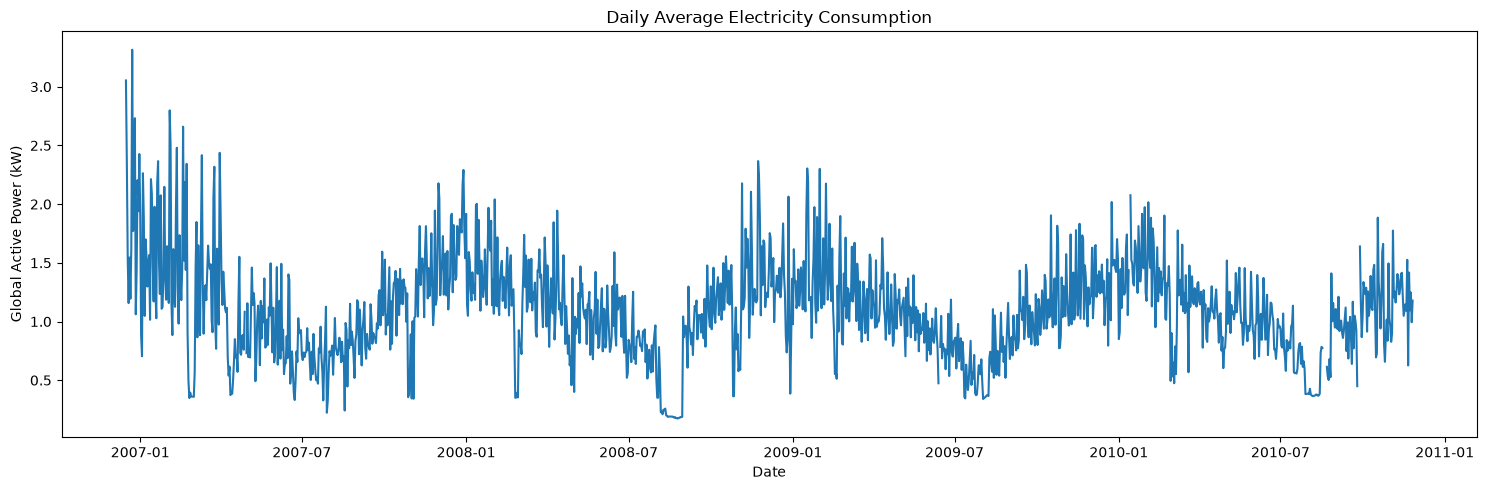

In [11]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_power.index,
    daily_power.values
)

plt.title(
    "Daily Average Electricity Consumption"
)

plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")

plt.tight_layout()

plt.show()

# 4. Daily consumption pattern

In [12]:
df["hour"] = df["timestamp"].dt.hour

In [13]:
hourly_profile = (
    df.groupby("hour")[target]
    .mean()
)

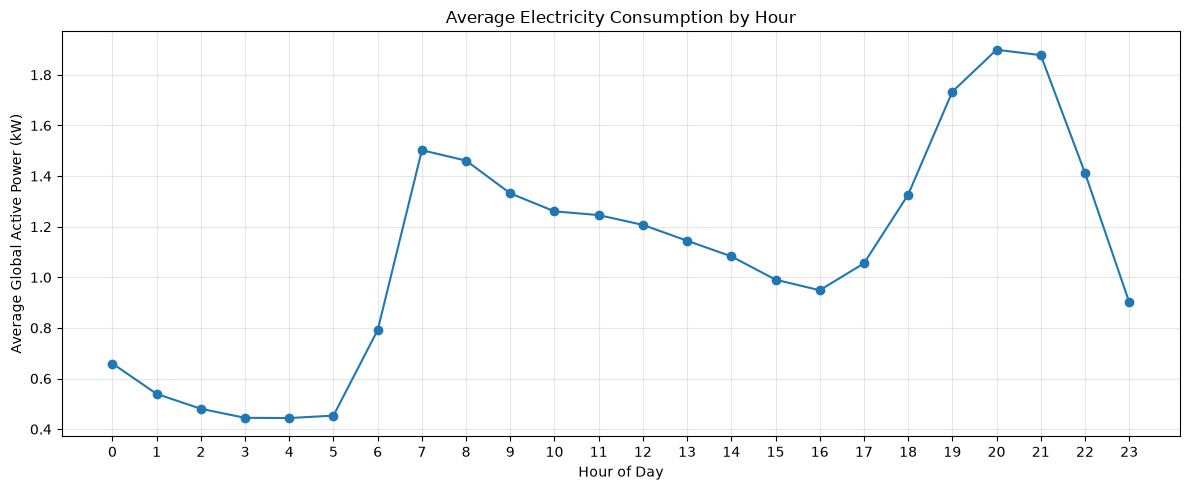

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker="o"
)

plt.title(
    "Average Electricity Consumption by Hour"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power (kW)")

plt.xticks(range(24))

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# 4. Weekday vs weekend

In [15]:
df["day_of_week"] = df["timestamp"].dt.dayofweek

In [16]:
weekday_profile = (
    df.groupby("day_of_week")[target]
    .mean()
)

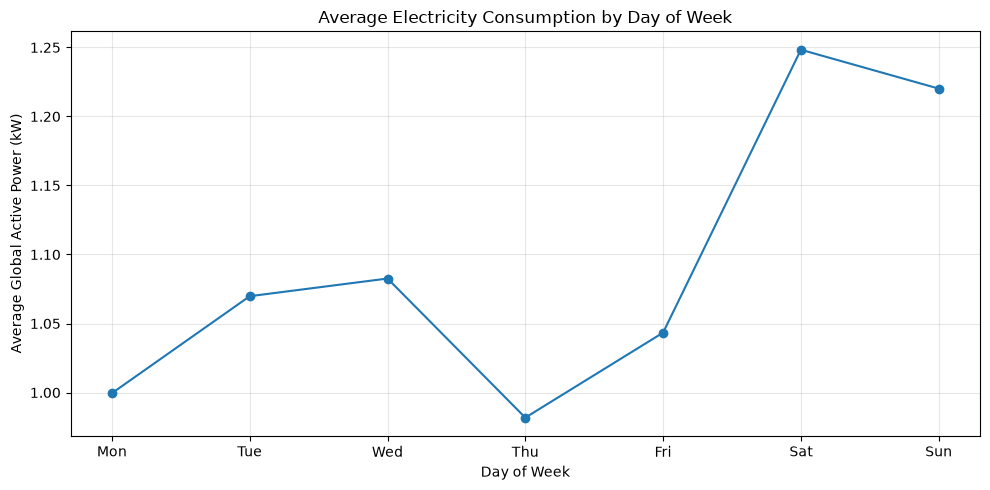

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekday_profile.index,
    weekday_profile.values,
    marker="o"
)

plt.title(
    "Average Electricity Consumption by Day of Week"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Global Active Power (kW)")

plt.xticks(
    range(7),
    [
        "Mon",
        "Tue",
        "Wed",
        "Thu",
        "Fri",
        "Sat",
        "Sun"
    ]
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# 5. Monthly pattern

In [18]:
df["month"] = df["timestamp"].dt.month

In [19]:
monthly_profile = (
    df.groupby("month")[target]
    .mean()
)

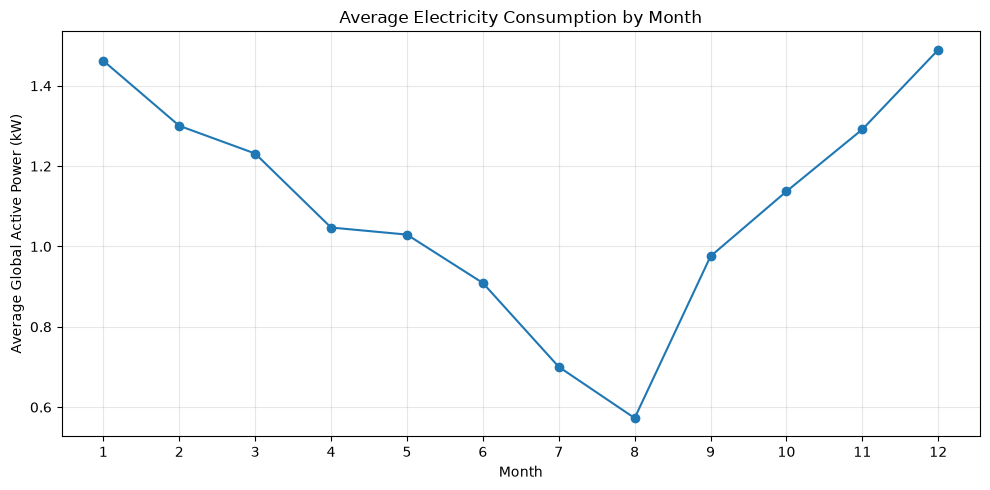

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_profile.index,
    monthly_profile.values,
    marker="o"
)

plt.title(
    "Average Electricity Consumption by Month"
)

plt.xlabel("Month")
plt.ylabel("Average Global Active Power (kW)")

plt.xticks(range(1, 13))

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# 6. Identify peak demand

In [21]:
top_consumption = (
    df[
        [
            "timestamp",
            "Global_active_power"
        ]
    ]
    .dropna()
    .sort_values(
        "Global_active_power",
        ascending=False
    )
    .head(20)
)

display(top_consumption)

,timestamp,Global_active_power
1150545,2009-02-22 17:09:00,11.122
112450,2007-03-04 19:34:00,10.670
112449,2007-03-04 19:33:00,10.650
1150544,2009-02-22 17:08:00,10.536
1029775,2008-11-30 20:19:00,10.348
968160,2008-10-19 01:24:00,10.290
586200,2008-01-27 19:24:00,10.162
112448,2007-03-04 19:32:00,10.154
1029773,2008-11-30 20:17:00,10.074
968161,2008-10-19 01:25:00,10.064


In [22]:
print(
    "Maximum active power:",
    df[target].max()
)

Maximum active power: 11.122


In [23]:
df["Global_active_power"].describe()

count    2.049280e+06
mean     1.091615e+00
std      1.057294e+00
min      7.600000e-02
25%      3.080000e-01
50%      6.020000e-01
75%      1.528000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64

In [27]:
df["Global_active_power"].max()

np.float64(11.122)

# 7. Calculate coverage

In [28]:
eda_df = df.copy()

In [29]:
eda_df = eda_df.set_index("timestamp")

eda_df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,is_measurement_missing,target_available,hour,day_of_week,month
timestamp,,,,,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,False,True,17,5,12
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,False,True,17,5,12
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,False,True,17,5,12
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,False,True,17,5,12
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,False,True,17,5,12


In [30]:
time_diff = (
    eda_df.index.to_series()
    .diff()
)

print(
    time_diff.value_counts().head(10)
)

timestamp
0 days 00:01:00    2075258
Name: count, dtype: int64


In [31]:
unexpected_intervals = time_diff[
    time_diff != pd.Timedelta(minutes=1)
].dropna()

print(
    "Unexpected intervals:",
    len(unexpected_intervals)
)

display(
    unexpected_intervals
)

Unexpected intervals: 0


Series([], Name: timestamp, dtype: timedelta64[us])

In [32]:
start = eda_df.index.min()
end = eda_df.index.max()

expected_minutes = (
    int((end - start).total_seconds() / 60)
    + 1
)

actual_records = len(eda_df)

print("Expected timeline records:", expected_minutes)
print("Actual records:", actual_records)

Expected timeline records: 2075259
Actual records: 2075259


In [33]:
coverage = (
    actual_records
    / expected_minutes
    * 100
)

print(
    f"Timeline coverage: {coverage:.2f}%"
)

Timeline coverage: 100.00%


# 8. Analyze missing data by year

In [34]:
missing_by_year = (
    eda_df[
        "is_measurement_missing"
    ]
    .groupby(
        eda_df.index.year
    )
    .sum()
)

print(missing_by_year)

timestamp
2006        4
2007     3931
2008      135
2009     4280
2010    17629
Name: is_measurement_missing, dtype: int64


In [35]:
total_by_year = (
    eda_df
    .groupby(
        eda_df.index.year
    )
    .size()
)

missing_percentage_by_year = (
    missing_by_year
    / total_by_year
    * 100
)

print(
    missing_percentage_by_year.round(2)
)

timestamp
2006    0.02
2007    0.75
2008    0.03
2009    0.81
2010    3.71
dtype: float64


# 9. Create hourly data

In [36]:
hourly_df = (
    eda_df[
        "Global_active_power"
    ]
    .resample("1h")
    .mean()
    .to_frame()
)

In [37]:
print(hourly_df.shape)

(34589, 1)


In [38]:
print(
    hourly_df.head()
)

                     Global_active_power
timestamp                               
2006-12-16 17:00:00             4.222889
2006-12-16 18:00:00             3.632200
2006-12-16 19:00:00             3.400233
2006-12-16 20:00:00             3.268567
2006-12-16 21:00:00             3.056467


# 10. Check hourly missingness

In [39]:
print(
    "Missing hourly targets:",
    hourly_df[
        "Global_active_power"
    ].isna().sum()
)

Missing hourly targets: 421


# 11. Compare minute vs hourly noise

In [40]:
minute_std = (
    eda_df[
        "Global_active_power"
    ].std()
)

hourly_std = (
    hourly_df[
        "Global_active_power"
    ].std()
)

print(
    "Minute-level std:",
    minute_std
)

print(
    "Hourly-level std:",
    hourly_std
)

Minute-level std: 1.0572941610939828
Hourly-level std: 0.8976190826386068


# 12. Plot one representative week

In [41]:
one_week = hourly_df.loc[
    "2007-01-01":"2007-01-07"
]

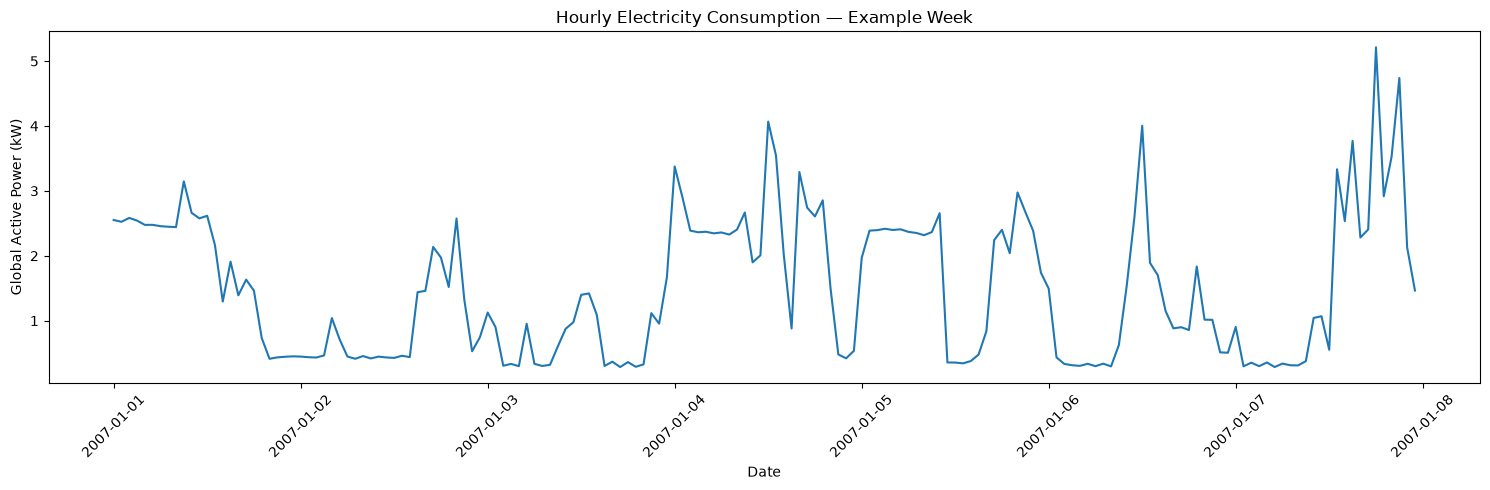

In [42]:
plt.figure(figsize=(15, 5))

plt.plot(
    one_week.index,
    one_week["Global_active_power"]
)

plt.title(
    "Hourly Electricity Consumption — Example Week"
)

plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# 13. Analyze weekly seasonality

In [43]:
eda_df["hour"] = eda_df.index.hour
eda_df["day_of_week"] = eda_df.index.dayofweek

In [44]:
weekly_profile = (
    eda_df
    .groupby(
        [
            "day_of_week",
            "hour"
        ]
    )["Global_active_power"]
    .mean()
)

In [45]:
weekly_profile_table = (
    weekly_profile
    .unstack("hour")
)

display(
    weekly_profile_table
)

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
0,0.531491,0.450318,0.413212,0.423549,0.428248,0.416705,0.819407,1.717465,1.497674,1.373733,...,0.757693,0.734081,0.706841,0.785288,1.092763,1.569511,1.891059,1.908203,1.390474,0.843882
1,0.607984,0.467204,0.439025,0.425868,0.439784,0.427126,0.856682,1.686488,1.606510,1.342482,...,1.013664,0.928795,0.868540,0.914604,1.168269,1.585670,1.865438,1.845749,1.463880,0.800541
2,0.563742,0.487532,0.474384,0.393366,0.404698,0.432288,0.905154,1.781989,1.640595,1.421146,...,1.071221,0.954609,0.919470,0.993782,1.188992,1.585141,1.781603,2.004720,1.357752,0.759258
3,0.571839,0.467033,0.437951,0.398958,0.426338,0.446182,0.889474,1.684447,1.577762,1.294534,...,0.705702,0.648629,0.634657,0.698958,1.070616,1.739859,1.963786,1.866883,1.347673,0.819051
4,0.567392,0.466689,0.411697,0.416350,0.429484,0.430946,0.905243,1.704821,1.577107,1.403459,...,1.000703,0.943429,0.885546,1.036914,1.192876,1.567192,1.701913,1.653744,1.297229,0.832834
5,0.648263,0.530597,0.464433,0.459482,0.438570,0.480753,0.585523,1.264521,1.420411,1.385149,...,1.518166,1.366778,1.376441,1.576265,1.847656,2.068611,1.936295,1.771959,1.647327,1.432982
6,1.132296,0.911564,0.727319,0.599044,0.541150,0.543591,0.572197,0.658517,0.897622,1.098036,...,1.525414,1.369968,1.263393,1.393620,1.739481,2.027533,2.157310,2.092624,1.387676,0.834612


# 14. Visualize the weekly profile

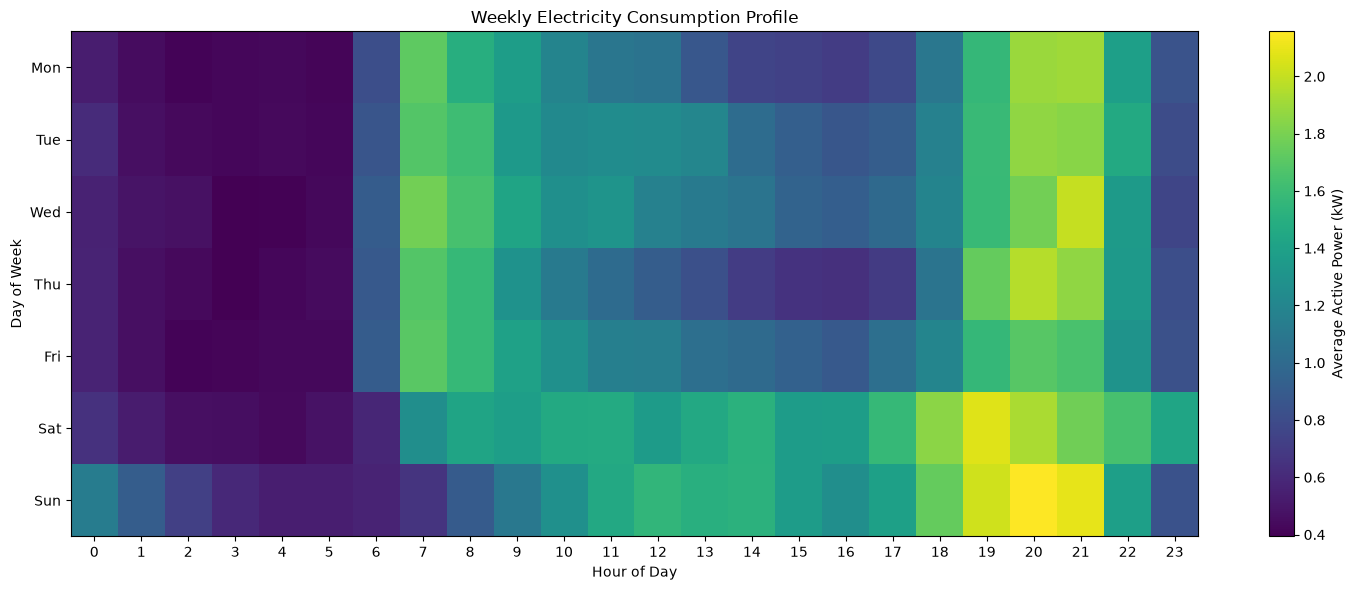

In [46]:
plt.figure(figsize=(15, 6))

plt.imshow(
    weekly_profile_table,
    aspect="auto"
)

plt.colorbar(
    label="Average Active Power (kW)"
)

plt.title(
    "Weekly Electricity Consumption Profile"
)

plt.xlabel("Hour of Day")

plt.ylabel("Day of Week")

plt.xticks(
    range(24),
    range(24)
)

plt.yticks(
    range(7),
    [
        "Mon",
        "Tue",
        "Wed",
        "Thu",
        "Fri",
        "Sat",
        "Sun"
    ]
)

plt.tight_layout()

plt.show()

# 15. Correlation analysis

In [47]:
measurement_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

correlation_matrix = (
    eda_df[
        measurement_columns
    ]
    .corr()
)

display(
    correlation_matrix.round(3)
)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000,0.247,-0.400,0.999,0.484,0.435,0.639
Global_reactive_power,0.247,1.000,-0.112,0.266,0.123,0.139,0.090
Voltage,-0.400,-0.112,1.000,-0.411,-0.196,-0.167,-0.268
Global_intensity,0.999,0.266,-0.411,1.000,0.489,0.440,0.627
Sub_metering_1,0.484,0.123,-0.196,0.489,1.000,0.055,0.103
Sub_metering_2,0.435,0.139,-0.167,0.440,0.055,1.000,0.081
Sub_metering_3,0.639,0.090,-0.268,0.627,0.103,0.081,1.000


In [48]:
print("Expected:", expected_minutes)
print("Actual:", actual_records)
print("Coverage:", coverage)

Expected: 2075259
Actual: 2075259
Coverage: 100.0


In [49]:
print(missing_percentage_by_year.round(2))

timestamp
2006    0.02
2007    0.75
2008    0.03
2009    0.81
2010    3.71
dtype: float64


In [50]:
print(hourly_df.shape)
print("Missing hourly targets:",
      hourly_df["Global_active_power"].isna().sum())

(34589, 1)
Missing hourly targets: 421


In [51]:
print("Minute std:", minute_std)
print("Hourly std:", hourly_std)

Minute std: 1.0572941610939828
Hourly std: 0.8976190826386068


In [ ]:
df["Global_active_power"].max()

np.float64(11.122)

In [52]:
display(correlation_matrix.round(3))

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000,0.247,-0.400,0.999,0.484,0.435,0.639
Global_reactive_power,0.247,1.000,-0.112,0.266,0.123,0.139,0.090
Voltage,-0.400,-0.112,1.000,-0.411,-0.196,-0.167,-0.268
Global_intensity,0.999,0.266,-0.411,1.000,0.489,0.440,0.627
Sub_metering_1,0.484,0.123,-0.196,0.489,1.000,0.055,0.103
Sub_metering_2,0.435,0.139,-0.167,0.440,0.055,1.000,0.081
Sub_metering_3,0.639,0.090,-0.268,0.627,0.103,0.081,1.000


In [53]:
hourly_df = hourly_df.rename(
    columns={
        "Global_active_power": "demand_kw"
    }
)

In [54]:
hourly_df.head()

,demand_kw
timestamp,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


# 16. Find top 20 hourly peaks

In [55]:
top_hourly_peaks = (
    hourly_df[
        "demand_kw"
    ]
    .dropna()
    .sort_values(
        ascending=False
    )
    .head(20)
)

display(top_hourly_peaks)

timestamp
2008-11-23 18:00:00    6.560533
2009-01-16 20:00:00    6.519633
2008-02-02 19:00:00    6.496033
2007-12-23 19:00:00    6.488000
2007-02-22 21:00:00    6.363867
2007-12-28 17:00:00    6.333667
2008-11-23 20:00:00    6.310567
2007-01-21 20:00:00    6.076567
2008-01-26 19:00:00    6.013800
2008-11-30 20:00:00    5.930500
2007-01-21 21:00:00    5.910767
2007-02-03 19:00:00    5.814667
2007-01-13 22:00:00    5.814267
2008-10-19 01:00:00    5.759067
2007-09-17 21:00:00    5.735767
2008-04-20 21:00:00    5.671300
2008-04-12 18:00:00    5.656433
2007-03-05 19:00:00    5.644900
2010-11-20 18:00:00    5.626833
2006-12-23 23:00:00    5.562467
Name: demand_kw, dtype: float64

In [56]:
print(
    "Maximum hourly demand:",
    top_hourly_peaks.max()
)

Maximum hourly demand: 6.560533333333334


# 17. Define a peak threshold

In [57]:
peak_threshold = (
    hourly_df["demand_kw"]
    .quantile(0.95)
)

print(
    "95th percentile:",
    peak_threshold
)

95th percentile: 2.865606666666666


In [58]:
hourly_df["is_peak"] = (
    hourly_df["demand_kw"]
    >= peak_threshold
)

In [59]:
print(
    hourly_df["is_peak"].value_counts()
)

is_peak
False    32880
True      1709
Name: count, dtype: int64


In [60]:
peak_by_hour = (
    hourly_df[
        hourly_df["is_peak"]
    ]
    .groupby(
        hourly_df[
            hourly_df["is_peak"]
        ].index.hour
    )
    .size()
)

In [61]:
print(peak_by_hour)

timestamp
0      18
1      11
2       4
4       1
5       1
6       6
7      77
8      53
9      26
10     39
11     65
12     75
13     70
14     61
15     55
16     50
17     69
18    129
19    234
20    284
21    250
22     90
23     41
dtype: int64


# 18. Peak percentage by hour

In [62]:
hourly_df["hour"] = hourly_df.index.hour

In [63]:
peak_rate_by_hour = (
    hourly_df
    .groupby("hour")["is_peak"]
    .mean()
    * 100
)

In [64]:
print(
    peak_rate_by_hour.round(2)
)

hour
0      1.25
1      0.76
2      0.28
3      0.00
4      0.07
5      0.07
6      0.42
7      5.34
8      3.68
9      1.80
10     2.71
11     4.51
12     5.20
13     4.86
14     4.23
15     3.82
16     3.47
17     4.79
18     8.95
19    16.23
20    19.69
21    17.34
22     6.25
23     2.85
Name: is_peak, dtype: float64


# 19. Peak behavior by weekday

In [65]:
hourly_df["day_of_week"] = (
    hourly_df.index.dayofweek
)

In [66]:
peak_rate_by_day = (
    hourly_df
    .groupby("day_of_week")["is_peak"]
    .mean()
    * 100
)

In [67]:
print(
    peak_rate_by_day.round(2)
)

day_of_week
0    3.11
1    4.27
2    4.21
3    3.60
4    3.06
5    8.18
6    8.17
Name: is_peak, dtype: float64


# 21. Visualize peak demand

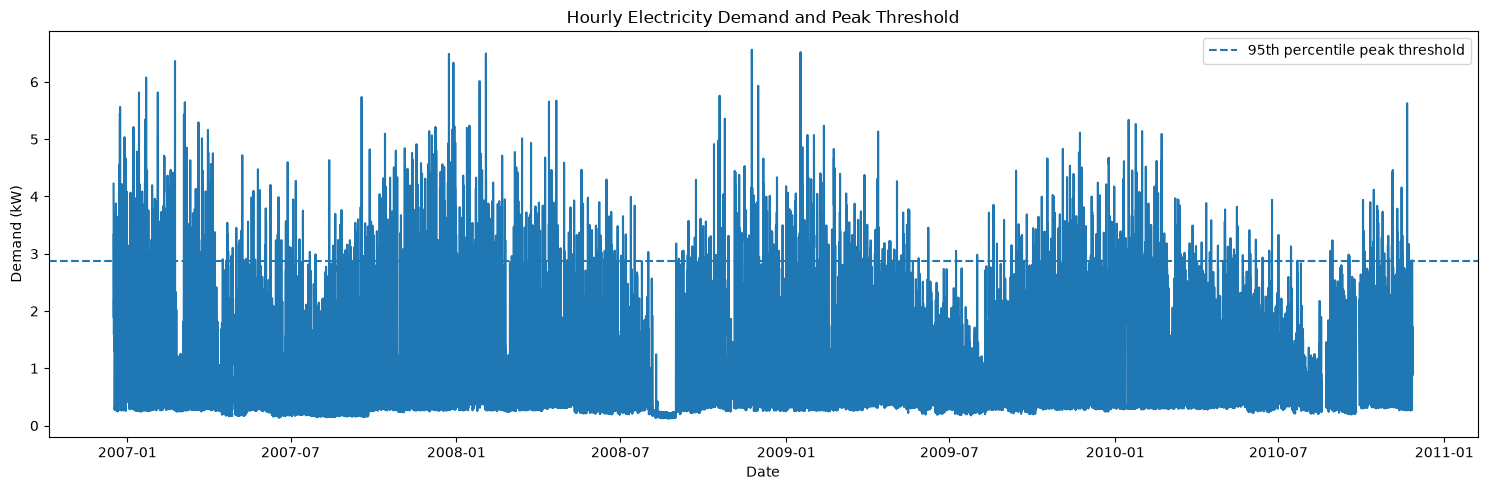

In [68]:
plt.figure(figsize=(15, 5))

plt.plot(
    hourly_df.index,
    hourly_df["demand_kw"]
)

plt.axhline(
    peak_threshold,
    linestyle="--",
    label="95th percentile peak threshold"
)

plt.title(
    "Hourly Electricity Demand and Peak Threshold"
)

plt.xlabel("Date")
plt.ylabel("Demand (kW)")

plt.legend()

plt.tight_layout()

plt.show()

In [69]:
daily_energy = (
    eda_df[
        "Global_active_power"
    ]
    .resample("D")
    .sum()
    / 60
)

In [70]:
daily_energy = daily_energy.rename(
    "energy_kwh"
)

In [71]:
print(
    daily_energy.describe()
)

count    1442.000000
mean       25.855581
std        10.288285
min         0.000000
25%        19.353308
50%        25.579633
75%        31.497658
max        79.556433
Name: energy_kwh, dtype: float64


# 21. Professional EDA summary


In [72]:
eda_summary = {
    "raw_records": int(len(df)),
    "measurement_outages": int(
        df["is_measurement_missing"].sum()
    ),
    "measurement_availability_pct": float(
        df["target_available"].mean() * 100
    ),
    "hourly_records": int(len(hourly_df)),
    "missing_hourly_targets": int(
        hourly_df["demand_kw"].isna().sum()
    ),
    "mean_demand_kw": float(
        df["Global_active_power"].mean()
    ),
    "median_demand_kw": float(
        df["Global_active_power"].median()
    ),
    "max_minute_demand_kw": float(
        df["Global_active_power"].max()
    ),
    "hourly_std_kw": float(
        hourly_df["demand_kw"].std()
    ),
    "peak_threshold_kw": float(
        peak_threshold
    )
}

eda_summary

{'raw_records': 2075259,
 'measurement_outages': 25979,
 'measurement_availability_pct': 98.7481562542314,
 'hourly_records': 34589,
 'missing_hourly_targets': 421,
 'mean_demand_kw': 1.0916150365006245,
 'median_demand_kw': 0.602,
 'max_minute_demand_kw': 11.122,
 'hourly_std_kw': 0.8976190826386068,
 'peak_threshold_kw': 2.865606666666666}

In [73]:
print("95th percentile:", peak_threshold)

95th percentile: 2.865606666666666


In [74]:
print(peak_rate_by_hour.round(2))

hour
0      1.25
1      0.76
2      0.28
3      0.00
4      0.07
5      0.07
6      0.42
7      5.34
8      3.68
9      1.80
10     2.71
11     4.51
12     5.20
13     4.86
14     4.23
15     3.82
16     3.47
17     4.79
18     8.95
19    16.23
20    19.69
21    17.34
22     6.25
23     2.85
Name: is_peak, dtype: float64


In [75]:
print(peak_rate_by_day.round(2))

day_of_week
0    3.11
1    4.27
2    4.21
3    3.60
4    3.06
5    8.18
6    8.17
Name: is_peak, dtype: float64


In [76]:
print(daily_energy.describe())

count    1442.000000
mean       25.855581
std        10.288285
min         0.000000
25%        19.353308
50%        25.579633
75%        31.497658
max        79.556433
Name: energy_kwh, dtype: float64


# 22. Create a clean hourly series

In [77]:
hourly_series = hourly_df["demand_kw"].copy()

In [78]:
hourly_series_clean = hourly_series.dropna()

In [79]:
print(
    "Hourly observations:",
    len(hourly_series_clean)
)

print(
    "Missing:",
    hourly_series.isna().sum()
)

Hourly observations: 34168
Missing: 421


# 23. Daily lag correlation

In [80]:
lag_24_corr = (
    hourly_series_clean
    .corr(
        hourly_series_clean.shift(24)
    )
)

print(
    "Lag-24 correlation:",
    lag_24_corr
)

Lag-24 correlation: 0.43518623866070283


In [81]:
lag_168_corr = (
    hourly_series_clean
    .corr(
        hourly_series_clean.shift(168)
    )
)

print(
    "Lag-168 correlation:",
    lag_168_corr
)

Lag-168 correlation: 0.4507513509347774


# 24. Analyze several important lags

In [82]:
lags = [
    1,
    2,
    3,
    6,
    12,
    24,
    48,
    72,
    168
]

lag_results = {}

for lag in lags:
    lag_results[lag] = (
        hourly_series_clean
        .corr(
            hourly_series_clean.shift(lag)
        )
    )

lag_results

{1: np.float64(0.7133433879229621),
 2: np.float64(0.46514944909057265),
 3: np.float64(0.286238379498231),
 6: np.float64(0.015961307942850503),
 12: np.float64(0.23811098044600582),
 24: np.float64(0.43518623866070283),
 48: np.float64(0.39901794239080896),
 72: np.float64(0.4087036415600946),
 168: np.float64(0.4507513509347774)}

In [83]:
lag_correlation = pd.DataFrame(
    {
        "lag_hours": list(lag_results.keys()),
        "correlation": list(lag_results.values())
    }
)

display(
    lag_correlation
)

,lag_hours,correlation
0,1,0.713343
1,2,0.465149
2,3,0.286238
3,6,0.015961
4,12,0.238111
5,24,0.435186
6,48,0.399018
7,72,0.408704
8,168,0.450751


# 25. Plot lag correlations

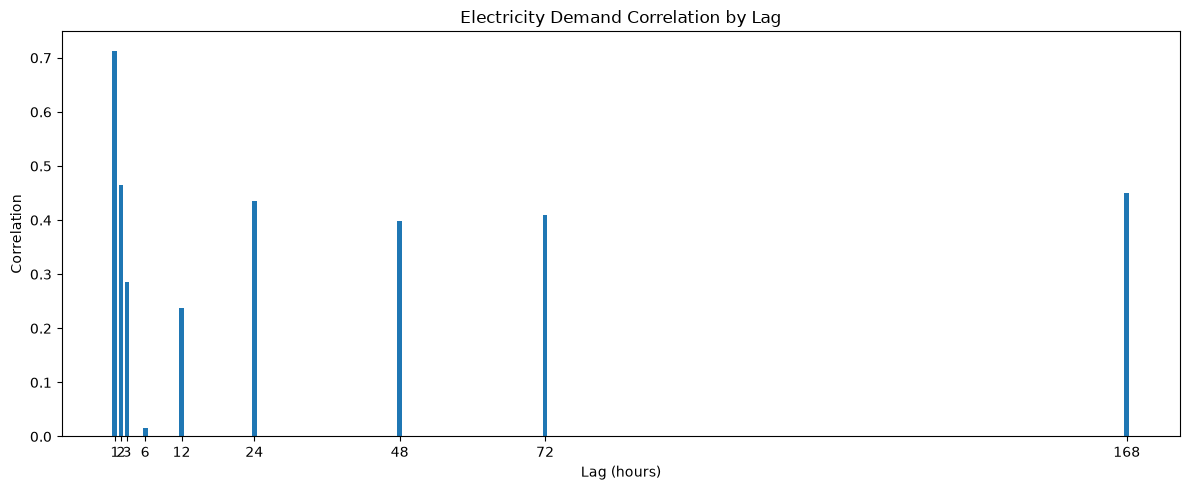

In [84]:
plt.figure(figsize=(12, 5))

plt.bar(
    lag_correlation["lag_hours"],
    lag_correlation["correlation"]
)

plt.title(
    "Electricity Demand Correlation by Lag"
)

plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")

plt.xticks(lags)

plt.tight_layout()

plt.show()

# 26 . Compare today vs yesterday


In [85]:
comparison = pd.DataFrame(
    {
        "current": hourly_series_clean,
        "previous_day": hourly_series_clean.shift(24),
        "previous_week": hourly_series_clean.shift(168)
    }
)

display(
    comparison.head(50)
)

,current,previous_day,previous_week
timestamp,,,
2006-12-16 17:00:00,4.222889,NaN,NaN
2006-12-16 18:00:00,3.632200,NaN,NaN
2006-12-16 19:00:00,3.400233,NaN,NaN
2006-12-16 20:00:00,3.268567,NaN,NaN
2006-12-16 21:00:00,3.056467,NaN,NaN
2006-12-16 22:00:00,2.200133,NaN,NaN
2006-12-16 23:00:00,2.061600,NaN,NaN
2006-12-17 00:00:00,1.882467,NaN,NaN
2006-12-17 01:00:00,3.349400,NaN,NaN


# 27. Autocorrelation plot

In [88]:
import statsmodels

In [89]:
from statsmodels.graphics.tsaplots import plot_acf

In [90]:
acf_series = hourly_series_clean.iloc[
    :24 * 30
]

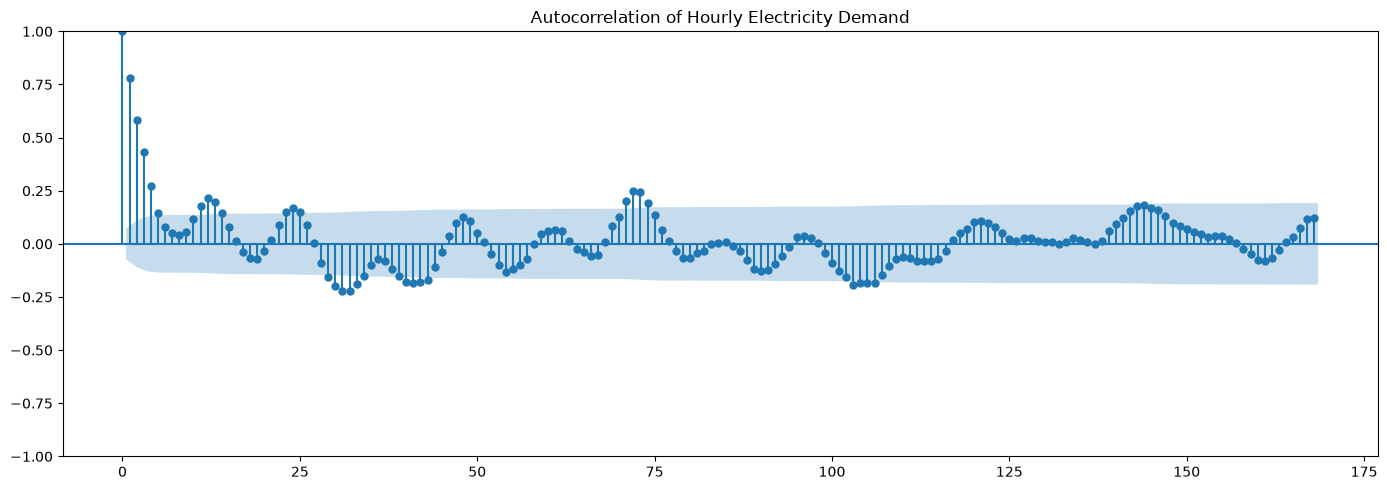

In [91]:
plt.figure(figsize=(14, 5))

plot_acf(
    acf_series,
    lags=168,
    ax=plt.gca()
)

plt.title(
    "Autocorrelation of Hourly Electricity Demand"
)

plt.tight_layout()

plt.show()

# 27. Test stationarity

In [92]:
from statsmodels.tsa.stattools import adfuller

In [93]:
adf_result = adfuller(
    hourly_series_clean
)

print(
    "ADF statistic:",
    adf_result[0]
)

print(
    "p-value:",
    adf_result[1]
)

ADF statistic: -14.237379512773874
p-value: 1.5588033375411734e-26


# 28. Rolling mean and volatility

In [94]:
rolling_mean = (
    hourly_series
    .rolling(24)
    .mean()
)

rolling_std = (
    hourly_series
    .rolling(24)
    .std()
)

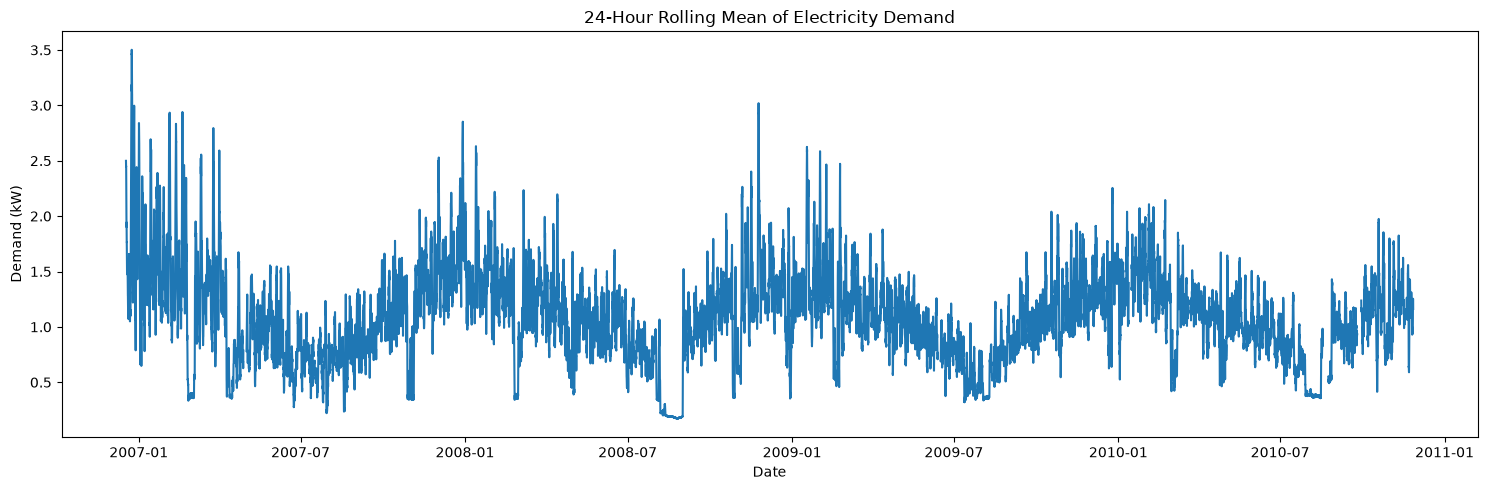

In [95]:
plt.figure(figsize=(15, 5))

plt.plot(
    rolling_mean.index,
    rolling_mean
)

plt.title(
    "24-Hour Rolling Mean of Electricity Demand"
)

plt.xlabel("Date")
plt.ylabel("Demand (kW)")

plt.tight_layout()

plt.show()

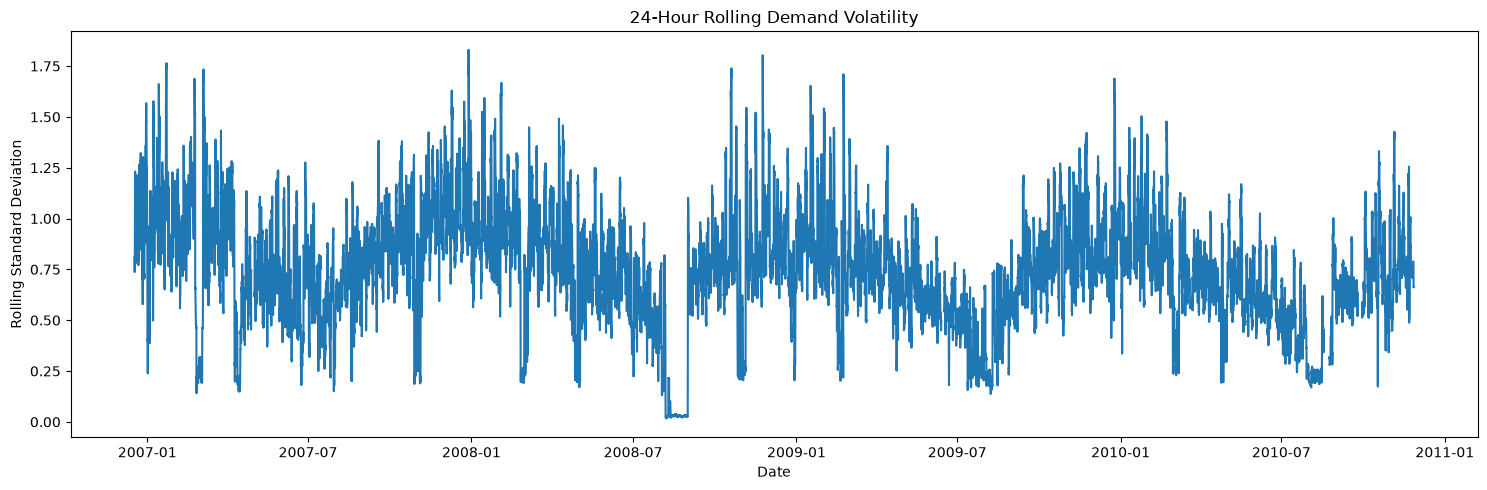

In [96]:
plt.figure(figsize=(15, 5))

plt.plot(
    rolling_std.index,
    rolling_std
)

plt.title(
    "24-Hour Rolling Demand Volatility"
)

plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")

plt.tight_layout()

plt.show()

In [97]:
import json

In [98]:
eda_results = {
    "raw_records": int(len(df)),
    "measurement_outages": int(
        df["is_measurement_missing"].sum()
    ),
    "measurement_availability_pct": float(
        df["target_available"].mean() * 100
    ),
    "hourly_records": int(len(hourly_df)),
    "missing_hourly_targets": int(
        hourly_df["demand_kw"].isna().sum()
    ),
    "mean_power_kw": float(
        df["Global_active_power"].mean()
    ),
    "median_power_kw": float(
        df["Global_active_power"].median()
    ),
    "max_minute_power_kw": float(
        df["Global_active_power"].max()
    ),
    "peak_threshold_kw": float(
        peak_threshold
    ),
    "mean_daily_energy_kwh": float(
        daily_energy.mean()
    ),
    "max_daily_energy_kwh": float(
        daily_energy.max()
    ),
    "lag_24_correlation": float(
        lag_24_corr
    ),
    "lag_168_correlation": float(
        lag_168_corr
    )
}

In [99]:
RESULTS_PATH = (
    PROJECT_ROOT
    / "results"
    / "reports"
    / "eda_summary.json"
)

with open(
    RESULTS_PATH,
    "w"
) as f:
    json.dump(
        eda_results,
        f,
        indent=4
    )

print(
    "EDA summary saved:",
    RESULTS_PATH
)

EDA summary saved: c:\Users\sayum\Desktop\smartenergy-ai\results\reports\eda_summary.json


In [100]:
print(lag_24_corr)
print(lag_168_corr)
display(lag_correlation)
print("ADF p-value:", adf_result[1])

0.43518623866070283
0.4507513509347774


,lag_hours,correlation
0,1,0.713343
1,2,0.465149
2,3,0.286238
3,6,0.015961
4,12,0.238111
5,24,0.435186
6,48,0.399018
7,72,0.408704
8,168,0.450751


ADF p-value: 1.5588033375411734e-26
